# 05 · Modelling: Can We Flag Churners Before They Leave?

A deliberately **simple, explainable** model: logistic regression. The goal is not leaderboard accuracy. It is to:
1. confirm which drivers still matter *when considered together* (odds ratios), and
2. check whether a basic model could rank customers for a retention campaign.

**Why recall matters more than accuracy here:** only 26.5% of customers churn, so a "model" that predicts *nobody churns* is already 73.5% accurate and completely useless. For retention, the costly mistake is **missing a churner** (a false negative means lost revenue). Wrongly contacting a loyal customer (a false positive) usually costs only a discount or a call. So we focus on **recall** (the share of actual churners we catch), with precision and ROC-AUC alongside it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent))
from src.churn_utils import load_clean, set_theme, save_fig, BLUE, ORANGE, GREY, INK, SEQ_BLUE

set_theme()
RANDOM_STATE = 42
df = load_clean()
print(df.shape)

(7043, 26)


## 1. Class imbalance

In [2]:
balance = df["Churn"].value_counts().to_frame("customers")
balance["share"] = (balance["customers"] / len(df)).round(3)
print(f"Accuracy of always predicting 'No churn': {balance.loc['No', 'share']:.1%}")
balance

Accuracy of always predicting 'No churn': 73.5%


,customers,share
Churn,,
No,5174,0.735
Yes,1869,0.265


## 2. Feature preparation

- **Categoricals** are one-hot encoded, with the lowest-risk level as the reference so odds ratios read as "risk vs the safest option".
- "No internet service" / "No phone service" are recoded to **"No"** on the add-on columns, because `InternetService_No` and `PhoneService` already carry that information. Leaving them in creates perfectly duplicated columns.
- **Tenure** is expressed in **years**, so its odds ratio reads "per extra year as a customer".
- **Dropped:** `TotalCharges` (≈ tenure × bill), `avg_monthly_spend` (r = 1.00 with `MonthlyCharges`), `tenure_band` and `num_services` (duplicates of other inputs), and **`MonthlyCharges`**. The bill is almost entirely determined by which services a customer holds (checked below). Including it alongside the services would make the service odds ratios unreliable.

In [3]:
model_df = df.copy()
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for c in addon_cols:
    model_df[c] = model_df[c].replace("No internet service", "No")
model_df["MultipleLines"] = model_df["MultipleLines"].replace("No phone service", "No")
model_df["tenure_years"] = model_df["tenure"] / 12

# Reference (baseline) level for each categorical = lowest-risk option
reference = {
    "gender": "Male", "SeniorCitizen": "No", "Partner": "Yes", "Dependents": "Yes",
    "PhoneService": "No", "MultipleLines": "No", "InternetService": "No",
    "OnlineSecurity": "Yes", "OnlineBackup": "Yes", "DeviceProtection": "Yes", "TechSupport": "Yes",
    "StreamingTV": "No", "StreamingMovies": "No",
    "Contract": "Two year", "PaperlessBilling": "No", "PaymentMethod": "Credit card (automatic)",
}
X_parts = [model_df[["tenure_years"]]]
for col, ref in reference.items():
    dummies = pd.get_dummies(model_df[col].astype(str), prefix=col, prefix_sep=" = ", dtype=int)
    X_parts.append(dummies.drop(columns=f"{col} = {ref}"))
X = pd.concat(X_parts, axis=1)
y = model_df["churn_flag"]
print("Feature matrix:", X.shape)

# How much of MonthlyCharges is explained by the service columns alone?
service_cols = [c for c in X.columns if c.split(" = ")[0] in
                ["PhoneService", "MultipleLines", "InternetService"] + addon_cols]
r2 = LinearRegression().fit(X[service_cols], model_df["MonthlyCharges"]).score(X[service_cols], model_df["MonthlyCharges"])
print(f"R² of MonthlyCharges ~ services held: {r2:.3f}  -> the bill is redundant with the service flags")

Feature matrix: (7043, 21)
R² of MonthlyCharges ~ services held: 0.999  -> the bill is redundant with the service flags


## 3. Train / test split (stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} rows, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]:,} rows, churn rate {y_test.mean():.1%}")

Train: 5,282 rows, churn rate 26.5%
Test:  1,761 rows, churn rate 26.5%


## 4. Fit two versions

- **Standard** logistic regression, which optimises overall fit.
- **Class-weighted** (`class_weight="balanced"`), which treats a missed churner as more costly. This is the retention-friendly version.

In [5]:
models = {
    "Standard": LogisticRegression(max_iter=5000),
    "Class-weighted": LogisticRegression(max_iter=5000, class_weight="balanced"),
}
results, probas, preds = [], {}, {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)[:, 1]
    yhat = (p >= 0.5).astype(int)
    probas[name], preds[name] = p, yhat
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, yhat),
        "precision": precision_score(y_test, yhat),
        "recall": recall_score(y_test, yhat),
        "f1": f1_score(y_test, yhat),
        "roc_auc": roc_auc_score(y_test, p),
        "churners_caught": int(((yhat == 1) & (y_test == 1)).sum()),
        "churners_missed": int(((yhat == 0) & (y_test == 1)).sum()),
        "customers_flagged": int(yhat.sum()),
    })
baseline = {"model": "Always predict 'No churn'", "accuracy": (y_test == 0).mean(), "precision": np.nan,
            "recall": 0.0, "f1": 0.0, "roc_auc": 0.5, "churners_caught": 0,
            "churners_missed": int(y_test.sum()), "customers_flagged": 0}
metrics = pd.DataFrame([baseline] + results).set_index("model")
metrics.round(3)

,accuracy,precision,recall,f1,roc_auc,churners_caught,churners_missed,customers_flagged
model,,,,,,,,
Always predict 'No churn',0.735,NaN,0.000,0.000,0.500,0,467,0
Standard,0.801,0.648,0.548,0.594,0.845,256,211,395
Class-weighted,0.753,0.523,0.790,0.629,0.844,369,98,706


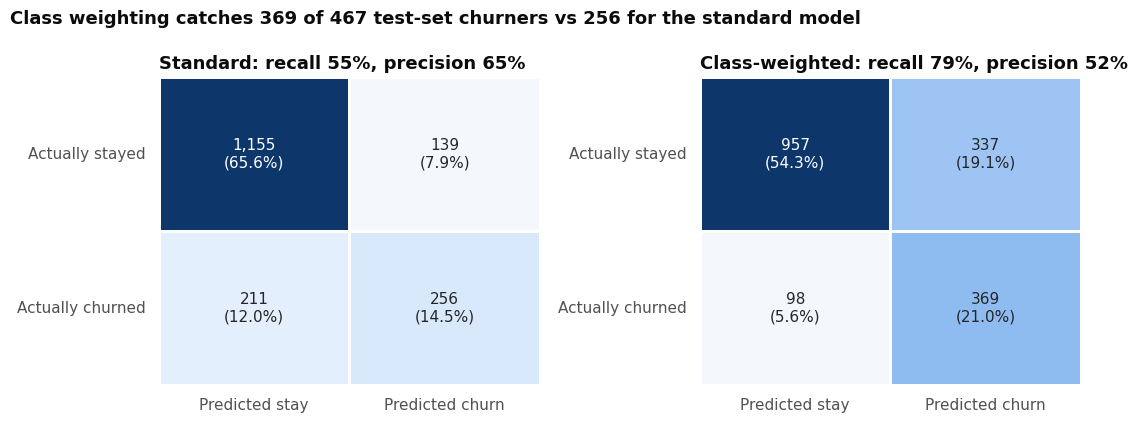

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    labels = np.array([[f"{v:,}\n({v / cm.sum():.1%})" for v in row] for row in cm])
    sns.heatmap(cm, annot=labels, fmt="", cmap=SEQ_BLUE, cbar=False, linewidths=2, linecolor="white",
                xticklabels=["Predicted stay", "Predicted churn"], yticklabels=["Actually stayed", "Actually churned"],
                annot_kws={"fontsize": 11}, ax=ax)
    r = metrics.loc[name]
    ax.set_title(f"{name}: recall {r['recall']:.0%}, precision {r['precision']:.0%}")
    ax.tick_params(axis="y", rotation=0)
fig.suptitle(f"Class weighting catches {metrics.loc['Class-weighted', 'churners_caught']} of {int(y_test.sum())} test-set churners "
             f"vs {metrics.loc['Standard', 'churners_caught']} for the standard model",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "15_confusion_matrices")
plt.show()

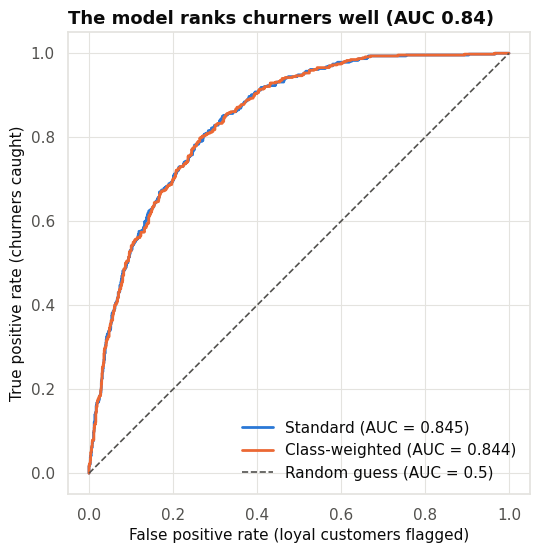

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, color in [("Standard", BLUE), ("Class-weighted", ORANGE)]:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {metrics.loc[name, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1.2, label="Random guess (AUC = 0.5)")
ax.set_xlabel("False positive rate (loyal customers flagged)")
ax.set_ylabel("True positive rate (churners caught)")
ax.set_title(f"The model ranks churners well (AUC {metrics.loc['Standard', 'roc_auc']:.2f})")
ax.legend(loc="lower right")
ax.set_aspect("equal")
save_fig(fig, "16_roc_curve")
plt.show()

Both versions rank customers almost identically (same AUC). Class weighting only moves the decision threshold, trading precision for recall. For a retention team that would rather make an extra call than lose a customer, the class-weighted version is the better operating point.

## 5. Odds ratios: what drives churn when everything is considered together?

An **odds ratio (OR)** compares a customer's odds of churning to the reference group, *holding all other factors constant*. OR = 2 means twice the odds, and OR = 0.5 means half the odds. These come from the standard (unweighted) model, whose coefficients are not distorted by re-weighting. scikit-learn applies light default L2 regularisation (C = 1), which shrinks coefficients slightly towards zero. Because the model is fit on observational data, these are **associations, not proof of cause**.

In [8]:
coefs = pd.Series(models["Standard"].coef_[0], index=X.columns)
odds = pd.DataFrame({"coef": coefs, "odds_ratio": np.exp(coefs)}).sort_values("odds_ratio")
odds["effect"] = np.where(odds["odds_ratio"] > 1, "raises churn odds", "lowers churn odds")
odds.round(3)

,coef,odds_ratio,effect
tenure_years,-0.388,0.678,lowers churn odds
PhoneService = Yes,-0.384,0.681,lowers churn odds
gender = Female,-0.005,0.995,lowers churn odds
Partner = No,0.002,1.002,raises churn odds
DeviceProtection = No,0.005,1.005,raises churn odds
PaymentMethod = Bank transfer (automatic),0.026,1.026,raises churn odds
OnlineBackup = No,0.135,1.144,raises churn odds
PaymentMethod = Mailed check,0.145,1.156,raises churn odds
SeniorCitizen = Yes,0.186,1.205,raises churn odds
Dependents = No,0.237,1.268,raises churn odds


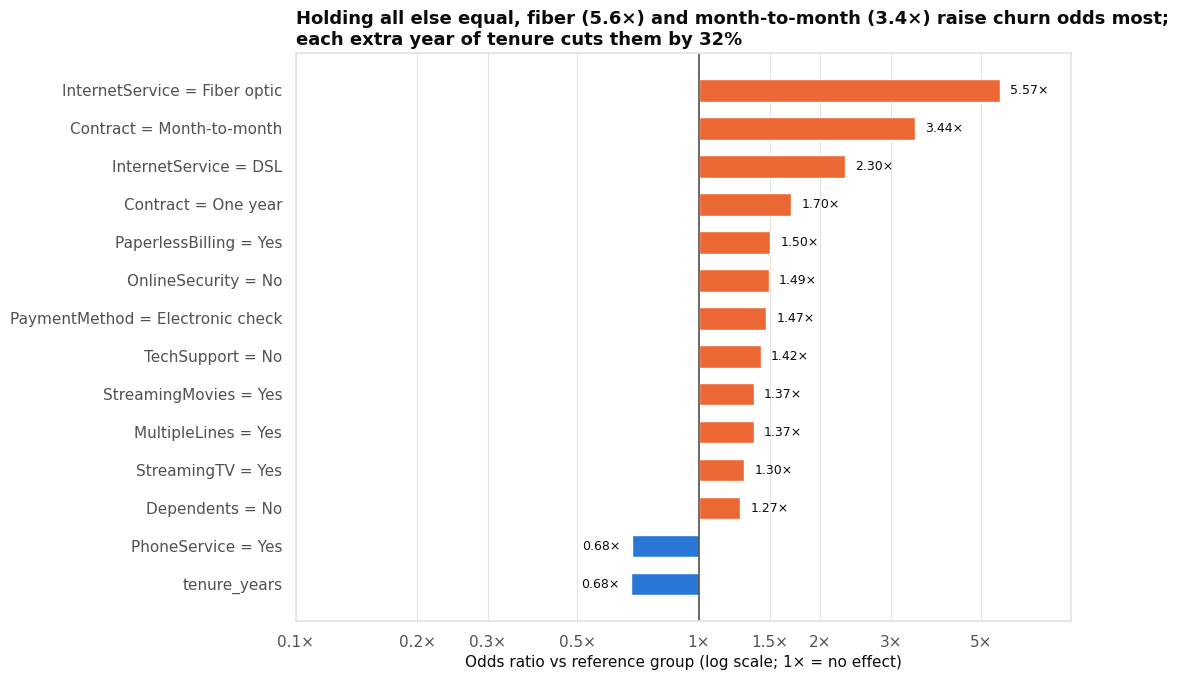

In [9]:
show = odds[(odds["odds_ratio"] >= 1.25) | (odds["odds_ratio"] <= 0.8)]
fig, ax = plt.subplots(figsize=(10, 0.42 * len(show) + 1.5))
colors = [ORANGE if v > 1 else BLUE for v in show["odds_ratio"]]
ax.barh(show.index, show["odds_ratio"] - 1, left=1, color=colors, height=0.6)
ax.axvline(1, color=GREY, lw=1.2)
ax.set_xscale("log")
ticks = [0.1, 0.2, 0.3, 0.5, 1, 1.5, 2, 3, 5]
ax.set_xticks(ticks, [f"{t:g}×" for t in ticks])
ax.set_xlim(min(0.1, show["odds_ratio"].min() * 0.8), max(5, show["odds_ratio"].max() * 1.5))
for i, v in enumerate(show["odds_ratio"]):
    ax.text(v * (1.06 if v > 1 else 0.94), i, f"{v:.2f}×", va="center", ha="left" if v > 1 else "right", fontsize=9)
ax.set_xlabel("Odds ratio vs reference group (log scale; 1× = no effect)")
ax.set_ylabel("")
ax.set_title(f"Holding all else equal, fiber ({odds.loc['InternetService = Fiber optic', 'odds_ratio']:.1f}×) and month-to-month "
             f"({odds.loc['Contract = Month-to-month', 'odds_ratio']:.1f}×) raise churn odds most;\n"
             f"each extra year of tenure cuts them by {1 - odds.loc['tenure_years', 'odds_ratio']:.0%}")
ax.grid(axis="y", visible=False)
save_fig(fig, "17_odds_ratios")
plt.show()

### Odds ratios in business terms

In [10]:
def or_line(feature, text):
    v = odds.loc[feature, "odds_ratio"]
    change = "no meaningful change in" if abs(v - 1) < 0.02 else f"{v - 1:+.0%}"
    print(f"- {text}: OR {v:.2f} ({change} odds)")

or_line("Contract = Month-to-month", "Month-to-month vs two-year contract")
or_line("Contract = One year", "One-year vs two-year contract")
or_line("tenure_years", "Each additional year of tenure")
or_line("InternetService = Fiber optic", "Fiber optic vs no internet")
or_line("InternetService = DSL", "DSL vs no internet")
or_line("PaymentMethod = Electronic check", "Electronic check vs automatic credit card")
or_line("TechSupport = No", "No tech support vs has tech support")
or_line("OnlineSecurity = No", "No online security vs has online security")
or_line("PaperlessBilling = Yes", "Paperless billing vs paper bill")
or_line("SeniorCitizen = Yes", "Senior citizen vs not")
or_line("gender = Female", "Female vs male")

- Month-to-month vs two-year contract: OR 3.44 (+244% odds)
- One-year vs two-year contract: OR 1.70 (+70% odds)
- Each additional year of tenure: OR 0.68 (-32% odds)
- Fiber optic vs no internet: OR 5.57 (+457% odds)
- DSL vs no internet: OR 2.30 (+130% odds)
- Electronic check vs automatic credit card: OR 1.47 (+47% odds)
- No tech support vs has tech support: OR 1.42 (+42% odds)
- No online security vs has online security: OR 1.49 (+49% odds)
- Paperless billing vs paper bill: OR 1.50 (+50% odds)
- Senior citizen vs not: OR 1.20 (+20% odds)
- Female vs male: OR 1.00 (no meaningful change in odds)


## 6. Using the model: who to call first?

Rank the test-set customers by predicted churn probability and check how many real churners fall in the top 20% of that ranking. This is the shortlist a retention team would actually work from.

In [11]:
p = probas["Standard"]
order = np.argsort(-p)
top_n = int(len(p) * 0.2)
caught_top20 = y_test.values[order[:top_n]].sum()
print(f"Top 20% of ranked customers ({top_n:,}) contain {caught_top20:,} of {int(y_test.sum()):,} churners "
      f"({caught_top20 / y_test.sum():.1%}), a churn rate of {caught_top20 / top_n:.1%} vs {y_test.mean():.1%} overall "
      f"({(caught_top20 / top_n) / y_test.mean():.1f}× lift).")

Top 20% of ranked customers (352) contain 234 of 467 churners (50.1%), a churn rate of 66.5% vs 26.5% overall (2.5× lift).


## Key Takeaways

- **Accuracy alone is misleading:** always predicting "no churn" scores **73.5%** while catching zero churners. The standard model reaches **80.1% accuracy** but catches only **55% of churners** (256 of 467 in the test set).
- **Class weighting is the better retention tool:** recall rises to **79%** (369 of 467 churners caught, only 98 missed). Precision drops to 52% and accuracy to 75.3%. In practice, about half of flagged customers would really leave, which is acceptable when an outreach call costs far less than a lost $74/month customer.
- **The ranking is solid:** ROC-AUC is **0.845** (standard) and **0.844** (weighted). The **top 20%** of customers by predicted risk contain **50.1% of all churners**, with a 66.5% churn rate, a **2.5× lift** over random targeting.
- **The drivers hold up when considered together (odds ratios):**
  - **Fiber optic: 5.57×** the churn odds of customers without internet (DSL: 2.30×). Fiber is the single biggest risk flag, even after accounting for contract and tenure.
  - **Month-to-month: 3.44×** the odds of a two-year contract (one-year: 1.70×).
  - **Each extra year of tenure cuts churn odds by 32%** (OR 0.68).
  - **Paperless billing (1.50×), no online security (1.49×), electronic check (1.47×) and no tech support (1.42×)** each add roughly 40-50% to the odds.
  - **Gender has no effect** (OR 1.00), and being a senior citizen adds only 20% once product and contract are accounted for.
- These are associations from observational data. They identify *who* to target, but A/B-tested retention offers are needed to prove *what* changes behaviour.